<a href="https://colab.research.google.com/github/pragatheesha/interactive_sales_dashboard/blob/main/gif_frame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

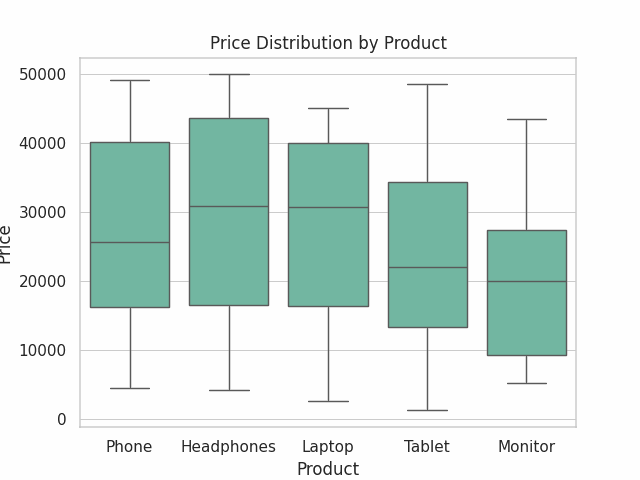

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
from IPython.display import Image, display

# Load CSV (upload sales_data.csv to Colab)
df = pd.read_csv("/content/sales_data.csv")

sns.set_theme(style="whitegrid", palette="Set2")

frames_dir = "/content/gif_frames"
os.makedirs(frames_dir, exist_ok=True)

frames = []

# Box plot
plt.figure()
sns.boxplot(x="Product", y="Price", data=df)
plt.title("Price Distribution by Product")
path = f"{frames_dir}/box.png"
plt.savefig(path)
plt.close()
frames.append(imageio.imread(path))

# Bar chart
plt.figure()
sns.barplot(x="Product", y="Total_Sales", data=df, estimator=sum)
plt.title("Total Sales by Product")
path = f"{frames_dir}/bar.png"
plt.savefig(path)
plt.close()
frames.append(imageio.imread(path))

# Heatmap
plt.figure()
corr = df[["Quantity", "Price", "Total_Sales"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
path = f"{frames_dir}/heat.png"
plt.savefig(path)
plt.close()
frames.append(imageio.imread(path))

# Violin plot
plt.figure()
sns.violinplot(x="Product", y="Total_Sales", data=df)
plt.title("Sales Distribution by Product")
path = f"{frames_dir}/violin.png"
plt.savefig(path)
plt.close()
frames.append(imageio.imread(path))

# Create GIF
gif_path = "/content/sales_dashboard.gif"
imageio.mimsave(gif_path, frames, duration=1.5)

# Display GIF in output
display(Image(filename=gif_path))
